# Loan Default Prediction - Exploratory Data Analysis
## Objective
Predict whether a loan applicant will default using supervised machine learning 
models (Logistic Regression, Random Forest, XGBoost). This notebook covers 
exploratory data analysis using SQL and Python to understand the dataset 
structure, class balance, missing values, and key feature relationships.

## Dataset
Sourced from the Home Credit Default Risk competition on Kaggle. The dataset 
contains 307,511 loan applications with 122 features. The target variable is 
binary: 1 = default, 0 = no default.


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load CSV into pandas
df = pd.read_csv('Data/application_train.csv')

# Create SQLite database
conn = sqlite3.connect('Data/loan_data.db')
df.to_sql('applications', conn, if_exists='replace', index=False)

print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

Rows: 307,511, Columns: 122


## 1. Dataset Overview

In [5]:
# Basic overview using SQL
query = """
SELECT 
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_income,
    ROUND(AVG(AMT_CREDIT), 2) as avg_credit,
    ROUND(AVG(AMT_ANNUITY), 2) as avg_annuity
FROM applications
"""
pd.read_sql_query(query, conn)


,total_applications,total_defaults,default_rate_pct,avg_income,avg_credit,avg_annuity
0,307511,24825,8.07,168797.92,599026.0,27108.57


## 2. Class Balance
Examining the distribution of the target variable to understand class imbalance.

In [6]:
# Class balance using SQL
query = """
SELECT 
    TARGET,
    COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM applications), 2) as percentage
FROM applications
GROUP BY TARGET
"""
class_balance = pd.read_sql_query(query, conn)
class_balance['TARGET'] = class_balance['TARGET'].map({0: 'No Default', 1: 'Default'})
print(class_balance)

       TARGET   count  percentage
0  No Default  282686       91.93
1     Default   24825        8.07


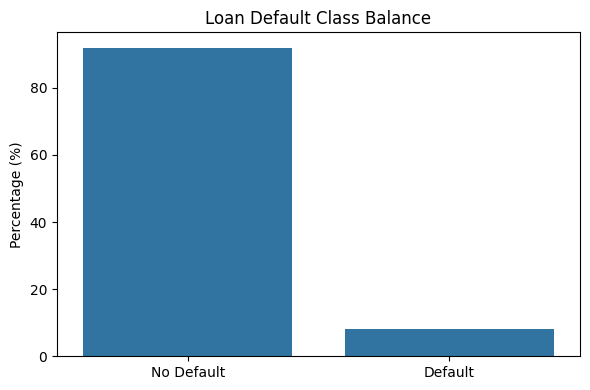

In [8]:
# Visualise class balance
plt.figure(figsize=(6,4))
sns.barplot(data=class_balance, x='TARGET', y='percentage')
plt.title('Loan Default Class Balance')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.tight_layout()
plt.show()

### Key Finding
The dataset is heavily imbalanced — 91.9% of applications did not default vs 
8.1% that did. This will be addressed during modelling using class weighting 
to prevent the model from simply predicting no default for every applicant.

## 3. Default Rate by Key Categories
Exploring how default rates vary across key categorical features using SQL aggregations.

In [9]:
# Default rate by contract type
query = """
SELECT 
    NAME_CONTRACT_TYPE,
    COUNT(*) as total_applications,
    SUM(TARGET) as defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct
FROM applications
GROUP BY NAME_CONTRACT_TYPE
ORDER BY default_rate_pct DESC
"""
print("Default Rate by Contract Type:")
print(pd.read_sql_query(query, conn))

Default Rate by Contract Type:
  NAME_CONTRACT_TYPE  total_applications  defaults  default_rate_pct
0         Cash loans              278232     23221              8.35
1    Revolving loans               29279      1604              5.48


In [10]:
# Default rate by gender
query = """
SELECT 
    CODE_GENDER,
    COUNT(*) as total_applications,
    SUM(TARGET) as defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct
FROM applications
GROUP BY CODE_GENDER
ORDER BY default_rate_pct DESC
"""
print("Default Rate by Gender:")
print(pd.read_sql_query(query, conn))

Default Rate by Gender:
  CODE_GENDER  total_applications  defaults  default_rate_pct
0           M              105059     10655             10.14
1           F              202448     14170              7.00
2         XNA                   4         0              0.00


In [11]:
# Default rate by income type
query = """
SELECT 
    NAME_INCOME_TYPE,
    COUNT(*) as total_applications,
    SUM(TARGET) as defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct
FROM applications
GROUP BY NAME_INCOME_TYPE
ORDER BY default_rate_pct DESC
"""
print("Default Rate by Income Type:")
print(pd.read_sql_query(query, conn))

Default Rate by Income Type:
       NAME_INCOME_TYPE  total_applications  defaults  default_rate_pct
0       Maternity leave                   5         2             40.00
1            Unemployed                  22         8             36.36
2               Working              158774     15224              9.59
3  Commercial associate               71617      5360              7.48
4         State servant               21703      1249              5.75
5             Pensioner               55362      2982              5.39
6               Student                  18         0              0.00
7           Businessman                  10         0              0.00
